In [ ]:
import sys
from pathlib import Path


project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
import pandas as pd
import numpy as np
import joblib

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

from ml.data_loader import load_train_test_data

In [5]:
X_train, X_test, y_train, y_test = load_train_test_data()

print(X_train.shape)
print(X_test.shape)

(226980, 30)
(56746, 30)


In [6]:
negative = (y_train == 0).sum()

positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

599.4761904761905


In [7]:
xgb_model = XGBClassifier(

    objective="binary:logistic",

    n_estimators=200,

    learning_rate=0.1,

    max_depth=6,

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    eval_metric="logloss"
)

In [8]:
xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:,1]

In [10]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy : 0.9995418179254926
Precision: 0.9259259259259259
Recall: 0.7894736842105263
F1 Score: 0.8522727272727273
ROC AUC: 0.970280080530004


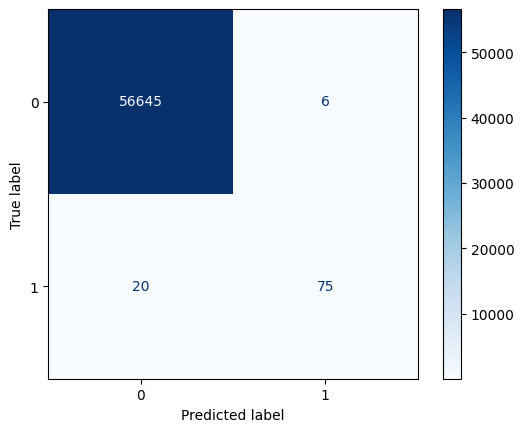

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.show()

In [12]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
14,V14,0.589521
4,V4,0.060966
12,V12,0.029192
3,V3,0.022872
8,V8,0.021666
19,V19,0.020954
10,V10,0.017257
11,V11,0.016996
18,V18,0.016317
13,V13,0.014065


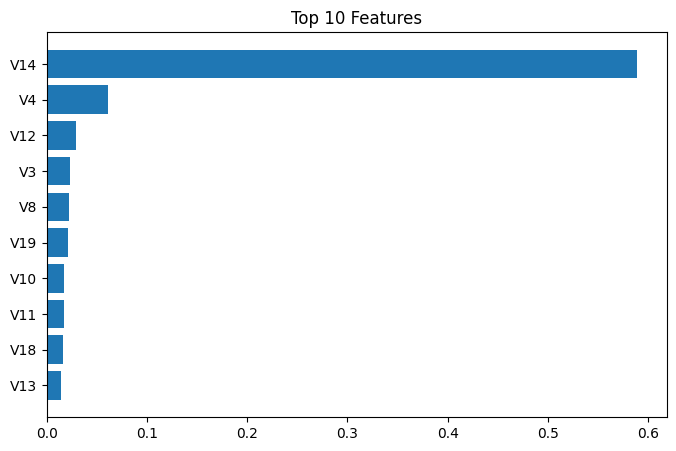

In [13]:
top = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Features")

plt.show()

In [14]:
joblib.dump(
    xgb_model,
    "C:\\Users\\vipul\\Desktop\\Fraud_Detection\\ml\\models\\xgboost.pkl"
)

['C:\\Users\\vipul\\Desktop\\Fraud_Detection\\ml\\models\\xgboost.pkl']